In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Seed for reproducibility — same random numbers every run
np.random.seed(42)

n = 50  # 50 houses

# Size between 500 and 3500 sq ft
size = np.random.randint(500, 3500, n)

# Price = real relationship + noise (real world is never perfect)
# True relationship: price = 150 × size + 50000
noise = np.random.normal(0, 20000, n)
price = 150 * size + 50000 + noise

print(f"Size range: {size.min()} - {size.max()} sq ft")
print(f"Price range: ${price.min():,.0f} - ${price.max():,.0f}")

Size range: 521 - 3419 sq ft
Price range: $135,271 - $582,443


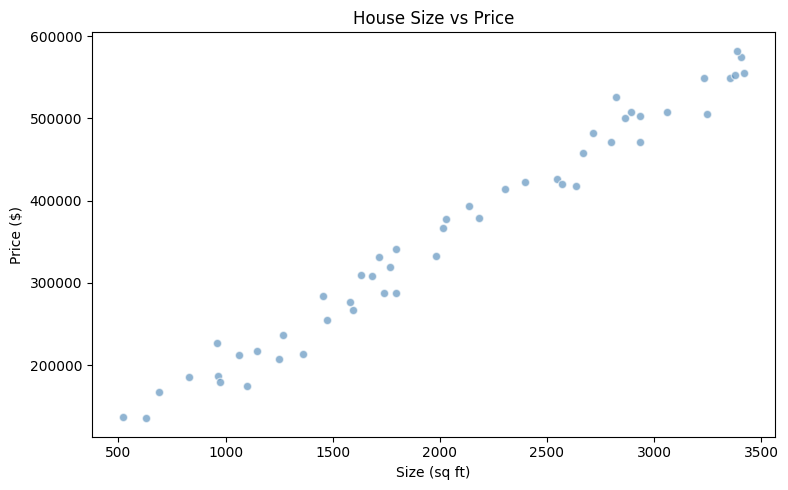

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(size, price, alpha=0.6, color='steelblue', edgecolors='white')
plt.xlabel("Size (sq ft)")
plt.ylabel("Price ($)")
plt.title("House Size vs Price")
plt.tight_layout()
plt.savefig("../data/01_scatter.png")  # save it — good habit
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression

# sklearn expects 2D input — reshape
X = size.reshape(-1, 1)  # shape: (50, 1)
y = price                 # shape: (50,)

model = LinearRegression()
model.fit(X, y)

print(f"Learned weight (w): {model.coef_[0]:,.2f}")
print(f"Learned bias  (b): {model.intercept_:,.2f}")
print(f"True weight was:    150.00")
print(f"True bias was:      50,000.00")

Learned weight (w): 154.15
Learned bias  (b): 42,766.09
True weight was:    150.00
True bias was:      50,000.00


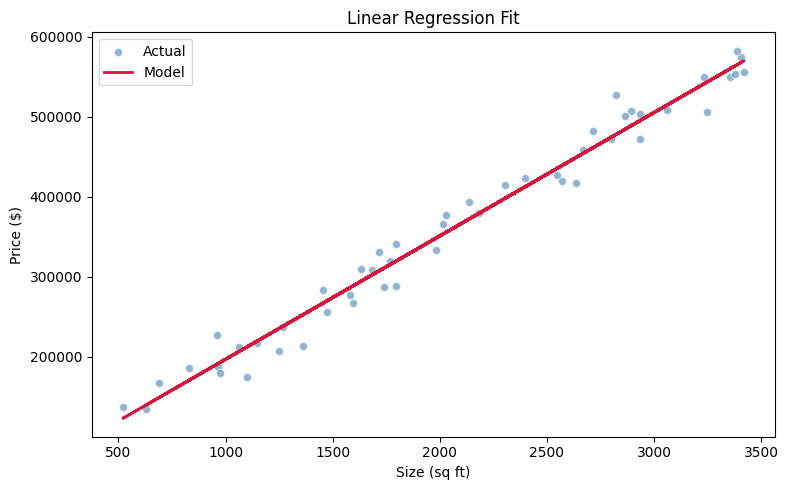

In [6]:
predicted = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(size, price, alpha=0.6, color='steelblue', 
            edgecolors='white', label='Actual')
plt.plot(size, predicted, color='crimson', linewidth=2, label='Model')
plt.xlabel("Size (sq ft)")
plt.ylabel("Price ($)")
plt.title("Linear Regression Fit")
plt.legend()
plt.tight_layout()
plt.savefig("../data/02_regression_line.png")
plt.show()

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y, predicted)

print(f"RMSE:  ${rmse:,.2f}")
print(f"R²:    {r2:.4f}")

RMSE:  $19,750.25
R²:    0.9779


In [8]:
from sklearn.model_selection import train_test_split

X = size.reshape(-1, 1)
y = price

# 80% train, 20% test — model never sees test data during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 40
Test samples:     10


In [9]:
model2 = LinearRegression()
model2.fit(X_train, y_train)  # train ONLY on training data

# Evaluate on both — compare the gap
train_rmse = np.sqrt(mean_squared_error(y_train, model2.predict(X_train)))
test_rmse  = np.sqrt(mean_squared_error(y_test,  model2.predict(X_test)))
train_r2   = r2_score(y_train, model2.predict(X_train))
test_r2    = r2_score(y_test,  model2.predict(X_test))

print(f"Train RMSE: ${train_rmse:,.2f}  |  Test RMSE: ${test_rmse:,.2f}")
print(f"Train R²:   {train_r2:.4f}      |  Test R²:   {test_r2:.4f}")

Train RMSE: $19,063.15  |  Test RMSE: $22,682.88
Train R²:   0.9796      |  Test R²:   0.9671


In [10]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()

# Build a proper dataframe
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target  # price in $100,000s

print(df.shape)         # how many rows and columns?
print(df.head())        # first 5 rows
print(df.describe())    # stats for every column

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%  

In [11]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Total missing: 0


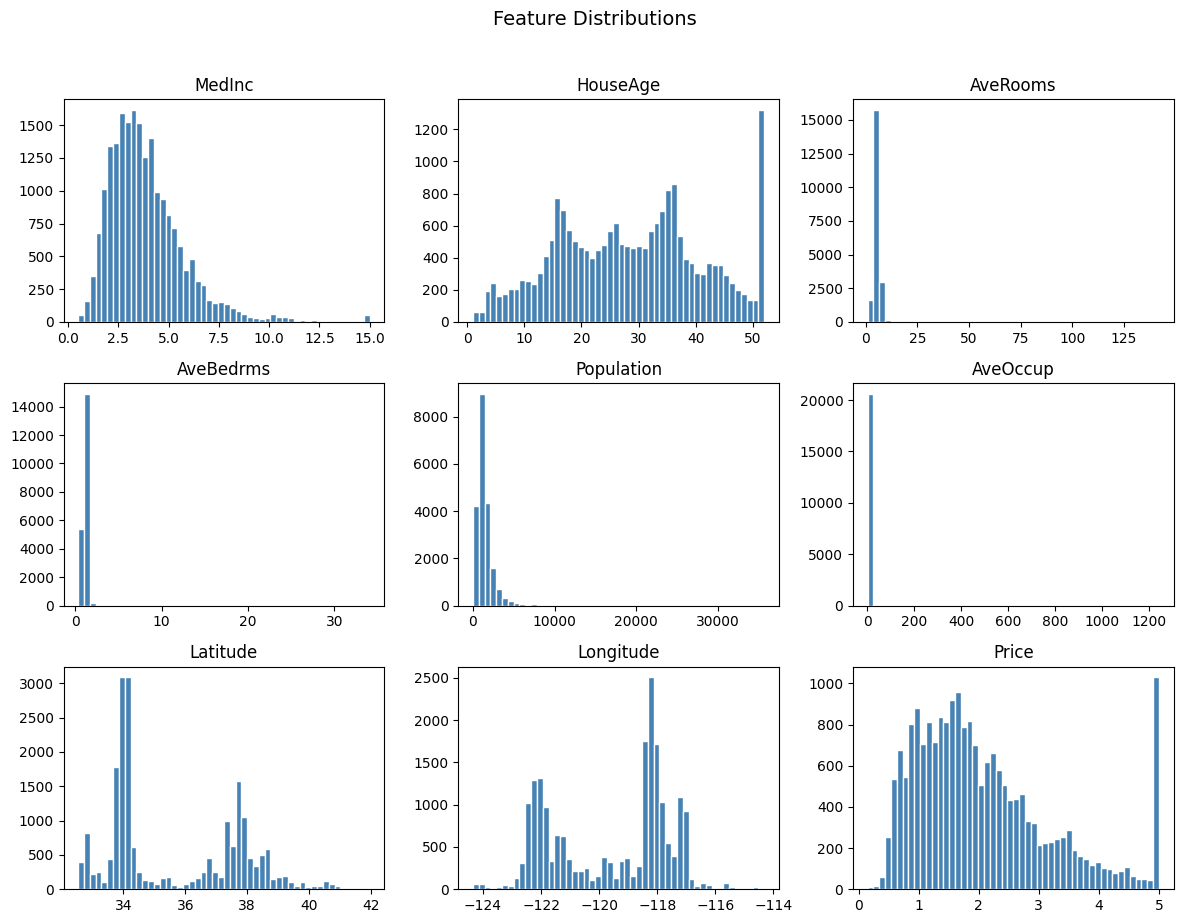

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle("Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/03_distributions.png")
plt.show()

In [13]:
correlations = df.corr()['Price'].sort_values(ascending=False)
print("Correlation with Price:")
print(correlations)

Correlation with Price:
Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


In [14]:
from sklearn.preprocessing import StandardScaler

# Separate features from target
X = df.drop('Price', axis=1)
y = df['Price']

# Scale: transforms each feature to mean=0, std=1
# Formula: scaled_value = (value - mean) / std
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling - MedInc mean:", df['MedInc'].mean().round(2))
print("After scaling  - MedInc mean:", X_scaled[:, 0].mean().round(4))
print("After scaling  - MedInc std: ", X_scaled[:, 0].std().round(4))
"""

The mathematical explanation becomes a `#` comment inline. Clean, no syntax errors.

"""

Before scaling - MedInc mean: 3.87
After scaling  - MedInc mean: 0.0
After scaling  - MedInc std:  1.0


'\n\nThe mathematical explanation becomes a `#` comment inline. Clean, no syntax errors.\n\n'

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

train_preds = model.predict(X_train)
test_preds  = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse  = np.sqrt(mean_squared_error(y_test, test_preds))
train_r2   = r2_score(y_train, train_preds)
test_r2    = r2_score(y_test, test_preds)

print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")
print(f"Train R²:   {train_r2:.4f}   |  Test R²:   {test_r2:.4f}")

Train RMSE: 0.7197  |  Test RMSE: 0.7456
Train R²:   0.6126   |  Test R²:   0.5758


In [16]:
feature_names = df.drop('Price', axis=1).columns
weights = pd.Series(model.coef_, index=feature_names)
weights_sorted = weights.sort_values()

print("Feature weights (scaled):")
print(weights_sorted.round(4))

Feature weights (scaled):
Latitude     -0.8966
Longitude    -0.8689
AveRooms     -0.3051
AveOccup     -0.0366
Population   -0.0023
HouseAge      0.1224
AveBedrms     0.3711
MedInc        0.8524
dtype: float64


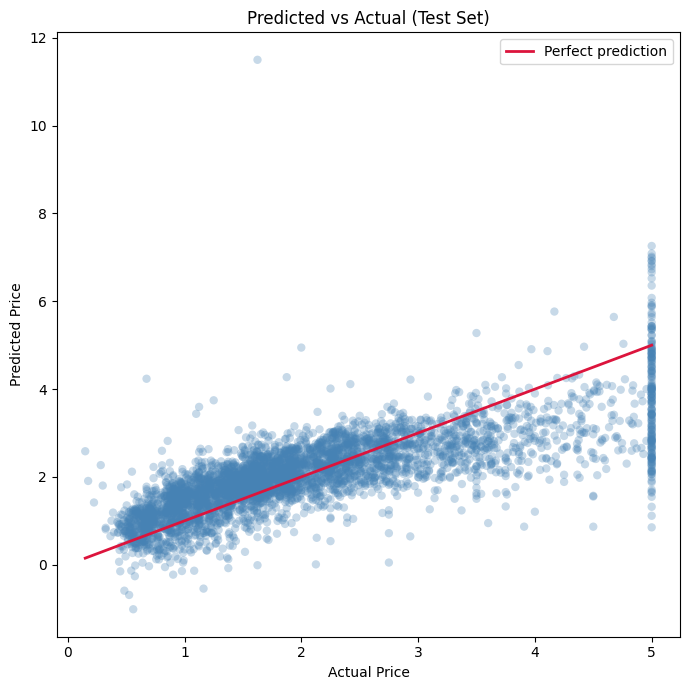

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_preds, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='crimson', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/04_pred_vs_actual.png")
plt.show()

In [18]:
results = {
    'model': 'LinearRegression',
    'features': list(df.drop('Price', axis=1).columns),
    'train_r2': round(train_r2, 4),
    'test_r2': round(test_r2, 4),
    'train_rmse': round(train_rmse, 4),
    'test_rmse': round(test_rmse, 4)
}

for k, v in results.items():
    print(f"{k}: {v}")

model: LinearRegression
features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
train_r2: 0.6126
test_r2: 0.5758
train_rmse: 0.7197
test_rmse: 0.7456


In [19]:
import joblib
import os

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save model and scaler together — always as a pair
joblib.dump(model, '../models/linear_regression.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Saved:")
print("  ../models/linear_regression.pkl")
print("  ../models/scaler.pkl")

# Verify by reloading and predicting one house
loaded_model  = joblib.load('../models/linear_regression.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')

sample = X_test[0].reshape(1, -1)  # already scaled — just testing reload
pred = loaded_model.predict(sample)
print(f"\nSample prediction after reload: ${pred[0]*100000:,.0f}")

Saved:
  ../models/linear_regression.pkl
  ../models/scaler.pkl

Sample prediction after reload: $71,912
